# Mushroom Classification
## TAKE-HOME CHALLENGE — MACHINE LEARNING & DEEP LEARNING

### Can Machine Learning Identify Whether a Mushroom is Edible or Poisonous?

**Nama: Fauzan Al Fajriansyah**  
**NIM: 09030282630035**  
**Jurusan: Teknik Komputer**  
**Tanggal Pengumpulan: 10 September 2026**  

---

## Petunjuk Umum

Notebook ini merupakan template yang harus dilengkapi oleh peserta.

Pada setiap bagian, perhatikan format berikut:

### 📌 TUGAS
Menjelaskan apa yang harus dikerjakan.

### 💡 PETUNJUK
Memberikan arahan atau konsep yang dapat digunakan.

### 💻 Tulis kode kamu di bawah ini
Area untuk menuliskan kode.

### 📝 ANALISIS / INSIGHT
Area untuk menjelaskan hasil yang diperoleh.

> **Catatan:** Jangan hanya menampilkan kode dan output. Berikan penjelasan terhadap hasil analisis dan keputusan yang kamu buat.


# 1. Problem Definition

## 📌 TUGAS

Jawab pertanyaan berikut:

1. Apa permasalahan utama yang ingin diselesaikan?
2. Apakah permasalahan ini termasuk Classification atau Regression?
3. Apa target yang akan diprediksi?
4. Mengapa permasalahan ini termasuk Classification?
5. Apa output yang diharapkan dari model?

## 📝 ANALISIS / JAWABAN

1. Permasalahan utama adalah membangun model Machine Learning yang dapat mengklasifikasikan jamur berdasarkan karakteristik fisiknya menjadi **Edible (dapat dimakan)** atau **Poisonous (beracun)**.
2. Permasalahan ini termasuk **Classification**, tepatnya binary classification, karena target hanya memiliki dua kategori.
3. Target yang diprediksi adalah kolom **class**, dengan `e` = Edible dan `p` = Poisonous.
4. Permasalahan termasuk Classification karena output yang ingin diprediksi berupa label/kategori, bukan nilai numerik kontinu.
5. Output yang diharapkan adalah prediksi kelas jamur, yaitu **Edible** atau **Poisonous**.

Model digunakan sebagai alat klasifikasi berdasarkan pola pada fitur fisik yang tersedia di dataset, bukan sebagai pengganti identifikasi jamur secara langsung di dunia nyata.


# 2. Import Libraries

## 📌 TUGAS

Import seluruh library yang diperlukan untuk:

- Data manipulation
- Data visualization
- Data preprocessing
- Machine Learning
- Model evaluation
- Hyperparameter tuning
- Deep Learning

## 💡 PETUNJUK

Beberapa library yang mungkin digunakan:

- pandas
- numpy
- matplotlib
- seaborn
- scikit-learn
- tensorflow / keras

## 💻 Tulis kode kamu di bawah ini:


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, mean_absolute_error, mean_squared_error, r2_score
)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)


# 3. Load Dataset

## 📌 TUGAS

Load dataset `mushrooms.csv`.

Setelah dataset berhasil dimuat:

1. Tampilkan 5 data pertama.
2. Tampilkan 5 data terakhir.

## 💡 PETUNJUK

Gunakan fungsi seperti:

- `pd.read_csv()`
- `head()`
- `tail()`

## 💻 Tulis kode kamu di bawah ini:


In [ ]:
df = pd.read_csv("mushrooms.csv")

display(df.head())
display(df.tail())


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,e,e,s,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,e,c,s,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,e,c,s,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,e,e,s,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,t,e,s,s,w,w,p,w,o,e,n,a,g


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
8119,e,k,s,n,f,n,a,c,b,y,e,?,s,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,e,?,s,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,e,?,s,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,t,?,s,k,w,w,p,w,o,e,w,v,l
8123,e,x,s,n,f,n,a,c,b,y,e,?,s,s,o,o,p,o,o,p,o,c,l


### Dataset Source

Dataset yang digunakan adalah **Mushroom Classification** dari Kaggle, sesuai sumber yang diberikan oleh panitia:

https://www.kaggle.com/datasets/uciml/mushroom-classification/data


# 4. Data Understanding

Pada tahap ini, pahami struktur dan karakteristik dataset sebelum melakukan analisis lebih lanjut.


## 4.1 Dataset Shape

### 📌 TUGAS

Tampilkan:

- Jumlah baris
- Jumlah kolom

### 💡 PETUNJUK

Gunakan:

`shape`

### 💻 Tulis kode kamu di bawah ini:


In [ ]:
rows, cols = df.shape
print(f"Jumlah baris  : {rows:,}")
print(f"Jumlah kolom  : {cols}")


Jumlah baris  : 8,124
Jumlah kolom  : 23


## 4.2 Dataset Information

### 📌 TUGAS

Tampilkan informasi dataset, termasuk:

- Nama kolom
- Tipe data
- Jumlah data
- Informasi non-null

### 💡 PETUNJUK

Gunakan:

- `columns`
- `info()`

### 💻 Tulis kode kamu di bawah ini:


In [ ]:
print("Nama kolom:")
print(df.columns.tolist())
print("\nInformasi dataset:")
df.info()


Nama kolom:
['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   

## 4.3 Unique Value Analysis

### 📌 TUGAS

Hitung jumlah nilai unik pada setiap kolom.

Kemudian identifikasi:

- Fitur dengan kategori paling banyak.
- Fitur dengan kategori paling sedikit.
- Fitur yang mungkin hanya memiliki satu nilai.

### 💡 PETUNJUK

Gunakan:

- `nunique()`
- `unique()`
- `value_counts()`

### 💻 Tulis kode kamu di bawah ini:


In [ ]:
unique_counts = df.nunique().sort_values()

display(unique_counts.to_frame("jumlah_unique_value"))

print("Fitur dengan kategori paling banyak:")
print(unique_counts[unique_counts == unique_counts.max()])

print("\nFitur dengan kategori paling sedikit:")
print(unique_counts[unique_counts == unique_counts.min()])

print("\nFitur yang hanya memiliki satu nilai:")
print(unique_counts[unique_counts == 1])

print("\nContoh kategori setiap fitur:")
for col in df.columns:
    print(f"{col}: {df[col].unique()}")


,jumlah_unique_value
veil-type,1
class,2
gill-attachment,2
gill-spacing,2
stalk-shape,2
gill-size,2
bruises,2
ring-number,3
stalk-surface-above-ring,4
veil-color,4


Fitur dengan kategori paling banyak:
gill-color    12
dtype: int64

Fitur dengan kategori paling sedikit:
veil-type    1
dtype: int64

Fitur yang hanya memiliki satu nilai:
veil-type    1
dtype: int64

Contoh kategori setiap fitur:
class: ['p' 'e']
cap-shape: ['x' 'b' 's' 'f' 'k' 'c']
cap-surface: ['s' 'y' 'f' 'g']
cap-color: ['n' 'y' 'w' 'g' 'e' 'p' 'b' 'u' 'c' 'r']
bruises: ['t' 'f']
odor: ['p' 'a' 'l' 'n' 'f' 'c' 'y' 's' 'm']
gill-attachment: ['f' 'a']
gill-spacing: ['c' 'w']
gill-size: ['n' 'b']
gill-color: ['k' 'n' 'g' 'p' 'w' 'h' 'u' 'e' 'b' 'r' 'y' 'o']
stalk-shape: ['e' 't']
stalk-root: ['e' 'c' 'b' 'r' '?']
stalk-surface-above-ring: ['s' 'f' 'k' 'y']
stalk-surface-below-ring: ['s' 'f' 'y' 'k']
stalk-color-above-ring: ['w' 'g' 'p' 'n' 'b' 'e' 'o' 'c' 'y']
stalk-color-below-ring: ['w' 'p' 'g' 'b' 'n' 'e' 'y' 'o' 'c']
veil-type: ['p']
veil-color: ['w' 'n' 'o' 'y']
ring-number: ['o' 't' 'n']
ring-type: ['p' 'e' 'l' 'f' 'n']
spore-print-color: ['k' 'n' 'u' 'h' 'w' 'r' 'o' 'y' 'b']


## 4.4 Dataset Summary

### 📌 TUGAS

Tampilkan ringkasan statistik atau ringkasan kategorikal dari dataset.

### 💡 PETUNJUK

Karena dataset didominasi data kategorikal, pertimbangkan penggunaan:

`describe(include="all")`

### 💻 Tulis kode kamu di bawah ini:


In [ ]:
display(df.describe(include="all").T)


,count,unique,top,freq
class,8124,2,e,4208
cap-shape,8124,6,x,3656
cap-surface,8124,4,y,3244
cap-color,8124,10,n,2284
bruises,8124,2,f,4748
odor,8124,9,n,3528
gill-attachment,8124,2,f,7914
gill-spacing,8124,2,c,6812
gill-size,8124,2,b,5612
gill-color,8124,12,b,1728


## 4.5 Target Analysis

### 📌 TUGAS

Identifikasi:

- Feature / Input (X)
- Target / Output (y)

Target utama pada dataset adalah:

`class`

Cari tahu kategori apa saja yang terdapat pada target.

### 💻 Tulis kode kamu di bawah ini:


In [ ]:
X = df.drop(columns="class")
y = df["class"]

print(f"Jumlah feature/input : {X.shape[1]}")
print("Target/output        : class")
print("Kategori target      :", y.unique().tolist())
print("\nDistribusi target:")
print(y.value_counts())


Jumlah feature/input : 22
Target/output        : class
Kategori target      : ['p', 'e']

Distribusi target:
class
e    4208
p    3916
Name: count, dtype: int64


# 5. Exploratory Data Analysis (EDA)

Pada tahap ini, lakukan eksplorasi data menggunakan visualisasi.

> Setiap visualisasi penting harus disertai dengan interpretasi.


## 5.1 Target Distribution

### 📌 TUGAS

Visualisasikan distribusi target `class`.

Analisis:

1. Berapa jumlah Edible?
2. Berapa jumlah Poisonous?
3. Apakah dataset balanced atau imbalanced?

### 💡 PETUNJUK

Gunakan salah satu atau beberapa:

- Count Plot
- Bar Chart
- Pie Chart

### 💻 Tulis kode kamu di bawah ini:


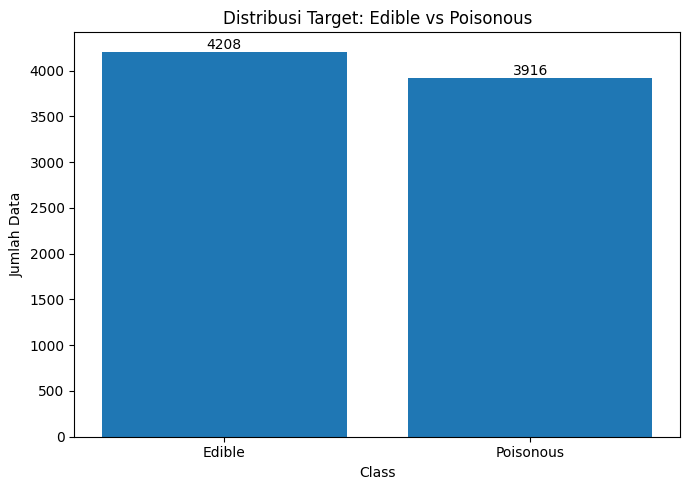

class
Edible       4208
Poisonous    3916
Name: count, dtype: int64

Persentase:
class
Edible       51.8
Poisonous    48.2
Name: count, dtype: float64


In [ ]:
target_counts = df["class"].map({"e": "Edible", "p": "Poisonous"}).value_counts()

plt.figure(figsize=(7, 5))
bars = plt.bar(target_counts.index, target_counts.values)
plt.title("Distribusi Target: Edible vs Poisonous")
plt.xlabel("Class")
plt.ylabel("Jumlah Data")
plt.bar_label(bars)
plt.tight_layout()
plt.show()

print(target_counts)
print("\nPersentase:")
print((target_counts / len(df) * 100).round(2))


### 📝 ANALISIS / INSIGHT

Dataset memiliki **8.124 data** dengan 4.208 jamur Edible dan 3.916 jamur Poisonous. Persentasenya sekitar 51,8% Edible dan 48,2% Poisonous. Perbedaannya relatif kecil sehingga dataset dapat dianggap **cukup balanced** dan tidak menunjukkan ketimpangan kelas yang berat. Kondisi ini juga mendukung penggunaan `stratify=y` saat pembagian data agar proporsi kedua kelas tetap terjaga.


## 5.2 Feature Distribution

### 📌 TUGAS

Pilih minimal **5 fitur** untuk dianalisis.

Rekomendasi:

- odor
- bruises
- gill-size
- cap-color
- habitat

Visualisasikan distribusi setiap fitur yang dipilih.

### 💻 Tulis kode kamu di bawah ini:


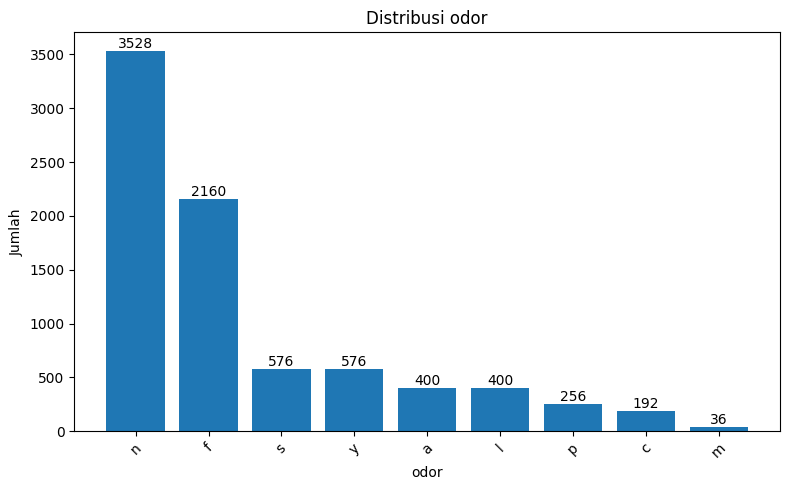

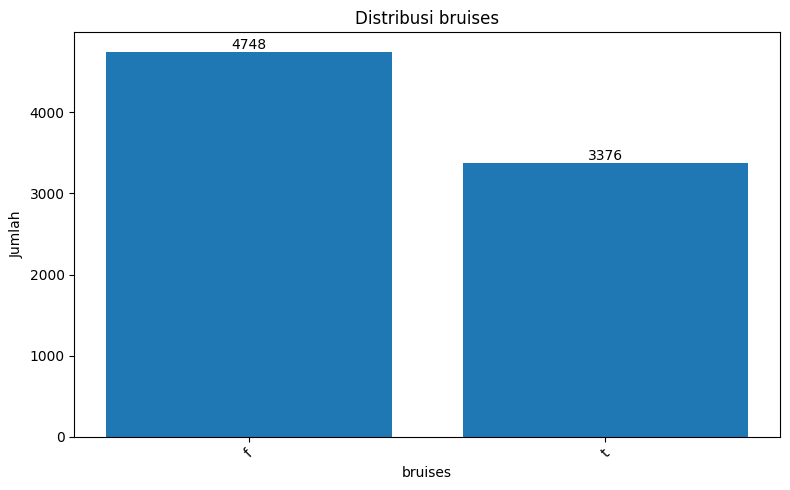

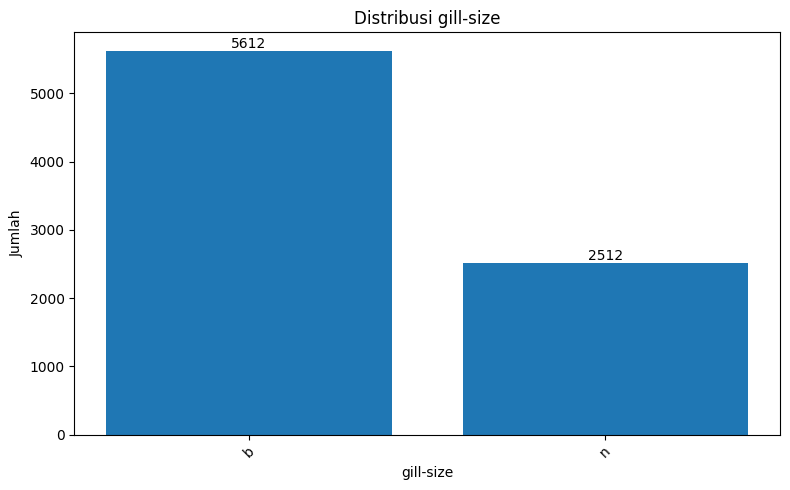

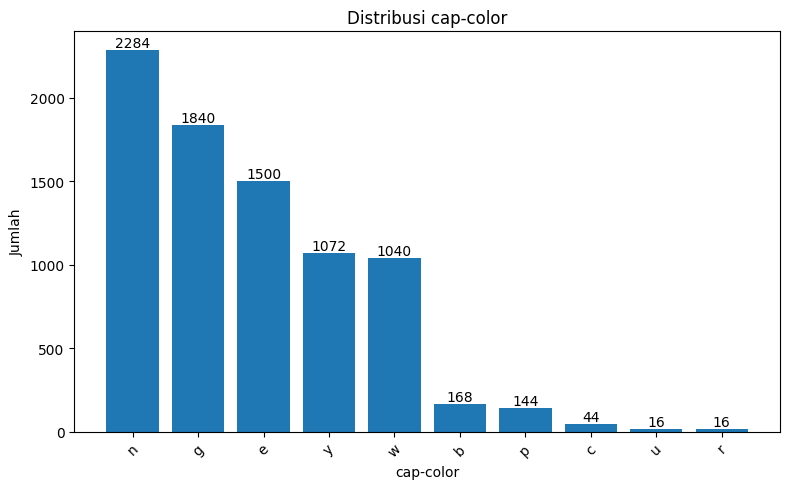

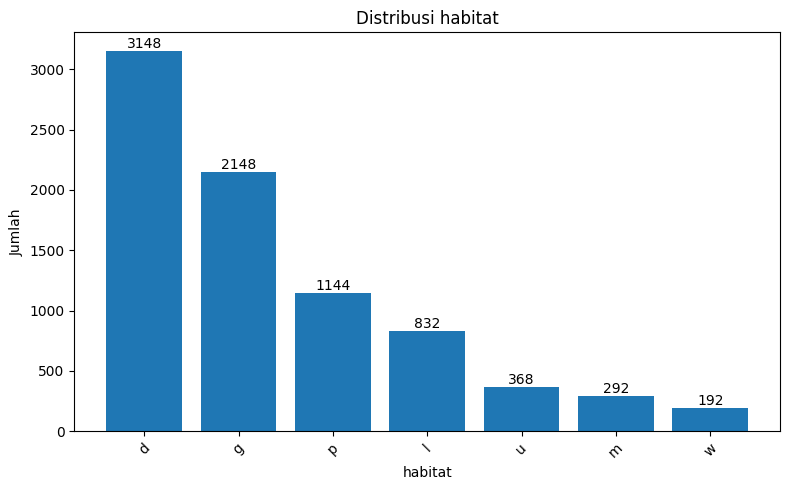

In [ ]:
selected_features = ["odor", "bruises", "gill-size", "cap-color", "habitat"]

for col in selected_features:
    counts = df[col].value_counts()
    plt.figure(figsize=(8, 5))
    bars = plt.bar(counts.index.astype(str), counts.values)
    plt.title(f"Distribusi {col}")
    plt.xlabel(col)
    plt.ylabel("Jumlah")
    plt.xticks(rotation=45)
    plt.bar_label(bars)
    plt.tight_layout()
    plt.show()


### 📝 ANALISIS / INSIGHT

1. **Odor** memiliki beberapa kategori dan distribusinya tidak merata; terdapat kategori aroma yang jauh lebih dominan dibandingkan kategori lainnya.
2. **Bruises** hanya memiliki dua kategori sehingga merupakan fitur biner yang sederhana, tetapi distribusinya tidak sepenuhnya sama.
3. **Gill-size** juga hanya memiliki dua kategori dan terlihat terdapat satu kategori yang lebih dominan. Hal ini menunjukkan bahwa distribusi fitur kategorikal pada dataset tidak selalu seimbang.
4. **Cap-color** dan **habitat** memiliki beberapa kategori dengan frekuensi berbeda-beda, sehingga keduanya berpotensi memberikan informasi tambahan untuk membedakan kelas jamur.


## 5.3 Feature vs Target

### 📌 TUGAS

Analisis hubungan antara fitur dengan target `class`.

Minimal analisis:

- odor vs class
- bruises vs class
- gill-size vs class
- habitat vs class

Kamu dapat menambahkan fitur lain jika diperlukan.

### 💡 PETUNJUK

Gunakan visualisasi yang dapat menunjukkan hubungan antara kategori fitur dan target.

### 💻 Tulis kode kamu di bawah ini:


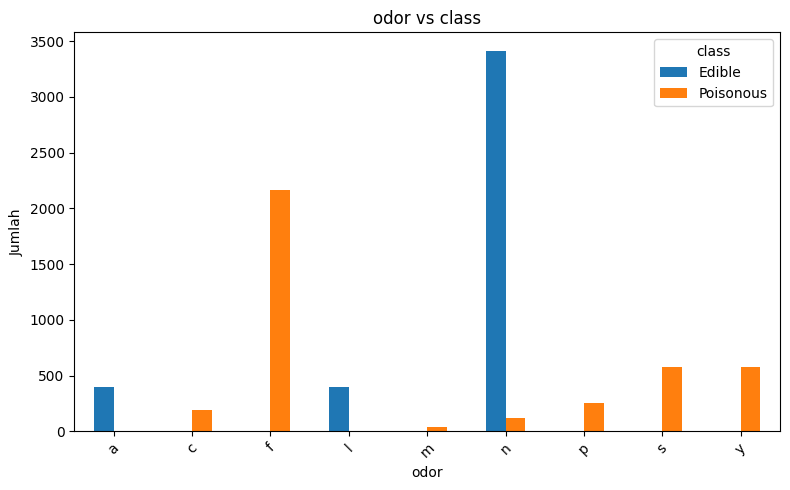

Proporsi class berdasarkan odor (%):


class,e,p
odor,,
a,100.0,0.0
c,0.0,100.0
f,0.0,100.0
l,100.0,0.0
m,0.0,100.0
n,96.6,3.4
p,0.0,100.0
s,0.0,100.0
y,0.0,100.0


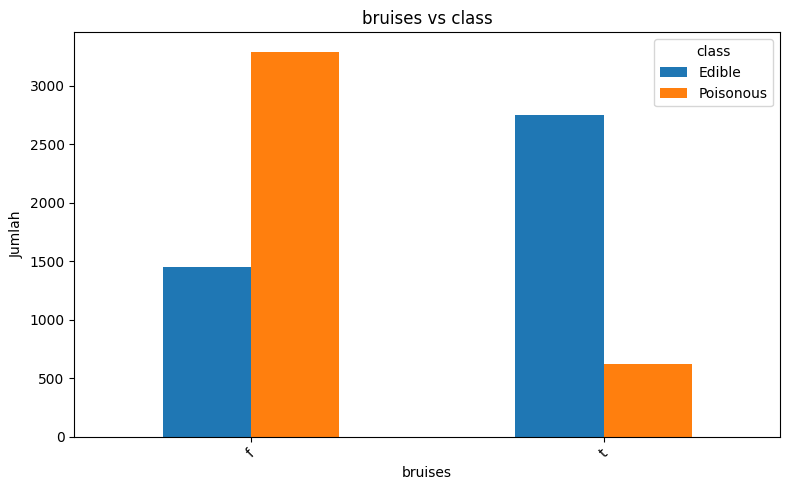

Proporsi class berdasarkan bruises (%):


class,e,p
bruises,,
f,30.67,69.33
t,81.52,18.48


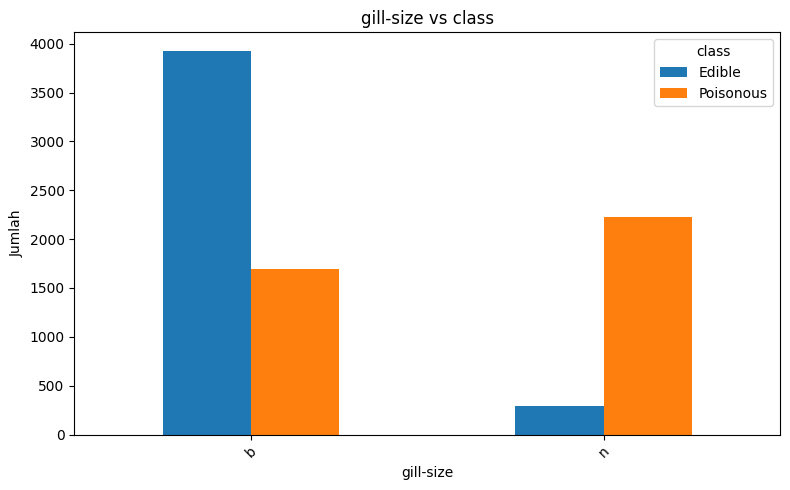

Proporsi class berdasarkan gill-size (%):


class,e,p
gill-size,,
b,69.85,30.15
n,11.46,88.54


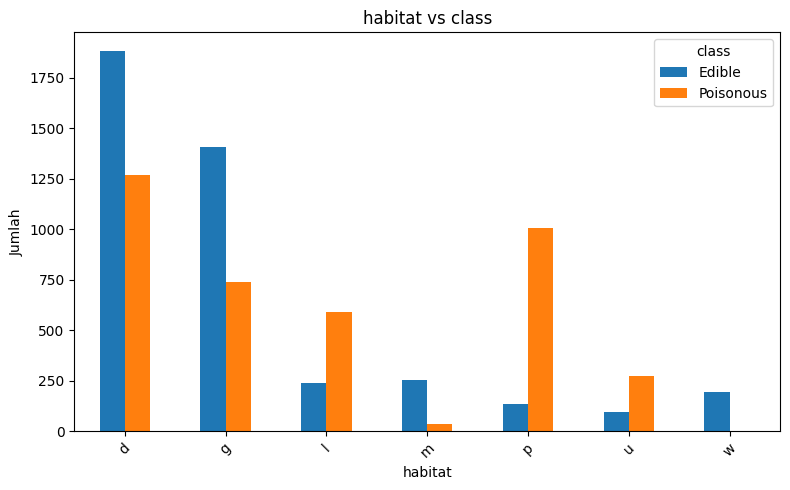

Proporsi class berdasarkan habitat (%):


class,e,p
habitat,,
d,59.72,40.28
g,65.55,34.45
l,28.85,71.15
m,87.67,12.33
p,11.89,88.11
u,26.09,73.91
w,100.00,0.00


In [ ]:
feature_target_cols = ["odor", "bruises", "gill-size", "habitat"]

for col in feature_target_cols:
    ct = pd.crosstab(df[col], df["class"])
    ax = ct.plot(kind="bar", figsize=(8, 5))
    plt.title(f"{col} vs class")
    plt.xlabel(col)
    plt.ylabel("Jumlah")
    plt.legend(["Edible", "Poisonous"], title="class")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    prop = pd.crosstab(df[col], df["class"], normalize="index") * 100
    print(f"Proporsi class berdasarkan {col} (%):")
    display(prop.round(2))


### 📝 ANALISIS / INSIGHT

1. **Odor** menunjukkan hubungan yang sangat jelas dengan target. Beberapa kategori aroma didominasi oleh satu kelas, sehingga fitur ini berpotensi menjadi salah satu pembeda utama antara Edible dan Poisonous.
2. **Gill-size** juga memperlihatkan perbedaan komposisi kelas. Kategori tertentu memiliki proporsi Poisonous yang lebih tinggi dibandingkan kategori lainnya.
3. **Bruises** memiliki perbedaan distribusi antara kedua kelas, sehingga informasi dari fitur biner ini tetap dapat membantu model.
4. **Habitat** memperlihatkan pola yang lebih beragam. Beberapa kategori habitat cenderung lebih banyak berisi salah satu kelas, tetapi hubungannya tidak sesederhana odor.
5. Secara keseluruhan, hasil EDA menunjukkan bahwa beberapa fitur kategorikal memiliki hubungan yang kuat dengan `class`, sehingga encoding yang tepat penting sebelum pemodelan.


# 6. Data Preprocessing

## 6.1 Missing Value Analysis

### 📌 TUGAS

Periksa apakah terdapat missing value pada dataset.

Periksa:

1. Missing value standar.
2. Nilai khusus yang mungkin merepresentasikan missing value, seperti `?`.

### 💡 PETUNJUK

Pertimbangkan penggunaan:

- `isnull()`
- `sum()`

Untuk nilai tertentu, kamu dapat melakukan pemeriksaan menggunakan perbandingan terhadap nilai tersebut.

### 💻 Tulis kode kamu di bawah ini:


In [ ]:
missing_standard = df.isnull().sum()
question_marks = (df == "?").sum()

print("Missing value standar:")
display(missing_standard[missing_standard > 0])

print("Jumlah nilai '?' per kolom:")
display(question_marks[question_marks > 0])

print(f"Total missing value standar: {missing_standard.sum():,}")
print(f"Total nilai '?': {question_marks.sum():,}")


Missing value standar:


,0


Jumlah nilai '?' per kolom:


,0
stalk-root,2480


Total missing value standar: 0
Total nilai '?': 2,480


### 📝 ANALISIS

1. Tidak terdapat missing value standar (`NaN`) pada dataset.
2. Terdapat nilai `?` pada fitur **stalk-root**. Nilai tersebut perlu diperlakukan sebagai missing value khusus.
3. Karena `?` merupakan kategori yang menunjukkan informasi tidak tersedia, penanganan yang dipilih adalah mengubahnya menjadi kategori khusus **`unknown`**, bukan menghapus seluruh baris.
4. Keputusan ini mempertahankan seluruh data dan menghindari kehilangan informasi dari ribuan observasi hanya karena satu fitur memiliki nilai yang tidak diketahui.


## 6.2 Duplicate Data

### 📌 TUGAS

Periksa apakah terdapat duplicate data.

Hitung:

- Jumlah duplicate.
- Persentase duplicate.

### 💡 PETUNJUK

Gunakan fungsi yang relevan untuk memeriksa duplicate data.

### 💻 Tulis kode kamu di bawah ini:


In [ ]:
duplicate_count = df.duplicated().sum()
duplicate_pct = duplicate_count / len(df) * 100

print(f"Jumlah duplicate   : {duplicate_count:,}")
print(f"Persentase duplicate: {duplicate_pct:.2f}%")


Jumlah duplicate   : 0
Persentase duplicate: 0.00%


### 📝 ANALISIS

Tidak ditemukan duplicate data pada dataset. Karena jumlah duplicate adalah 0, tidak ada baris yang perlu dihapus pada tahap ini. Dataset dapat dipertahankan tanpa tindakan khusus terhadap duplicate.


## 6.3 Constant / Uninformative Feature

### 📌 TUGAS

Periksa apakah terdapat fitur yang:

- Hanya memiliki satu nilai.
- Tidak memiliki variasi.
- Berpotensi tidak memberikan informasi kepada model.

Jika terdapat fitur tersebut, tentukan apakah fitur perlu dihapus.

### 💻 Tulis kode kamu di bawah ini:


In [ ]:
constant_features = [col for col in df.columns if df[col].nunique() == 1]

print("Fitur constant:", constant_features)
print("\nJumlah fitur constant:", len(constant_features))


Fitur constant: ['veil-type']

Jumlah fitur constant: 1


### 📝 ANALISIS

Ditemukan satu fitur constant, yaitu **`veil-type`**, karena hanya memiliki satu kategori. Fitur ini tidak memberikan variasi informasi kepada model sehingga diputuskan untuk **dihapus**. Menghapus fitur constant juga membuat representasi data lebih sederhana tanpa kehilangan informasi pembeda antar kelas.


## 6.4 Feature Encoding

### 📌 TUGAS

Karena dataset terdiri dari data kategorikal, lakukan encoding terhadap:

- Feature
- Target jika diperlukan

### 💡 PETUNJUK

Kamu dapat mempertimbangkan:

- One Hot Encoding
- Label Encoding
- Ordinal Encoding

### 💻 Tulis kode kamu di bawah ini:


In [ ]:
# Salinan data untuk preprocessing
df_prep = df.copy()

# Nilai '?' pada stalk-root diperlakukan sebagai kategori khusus
df_prep = df_prep.replace("?", "unknown")

# Hapus fitur constant
df_prep = df_prep.drop(columns=["veil-type"])

# Target encoding: e -> 0, p -> 1
df_prep["class"] = df_prep["class"].map({"e": 0, "p": 1})

feature_cols = [col for col in df_prep.columns if col != "class"]
categorical_features = feature_cols

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

print("Metode encoding feature : One Hot Encoding")
print("Jumlah feature sebelum encoding :", len(feature_cols))
print("Fitur yang dihapus              : veil-type")
print("Target encoding                 : e=0, p=1")


Metode encoding feature : One Hot Encoding
Jumlah feature sebelum encoding : 21
Fitur yang dihapus              : veil-type
Target encoding                 : e=0, p=1


### 📝 ANALISIS

1. **One Hot Encoding** digunakan untuk fitur kategorikal karena kategori pada dataset tidak memiliki urutan numerik yang bermakna. Dengan One Hot Encoding, setiap kategori direpresentasikan sebagai fitur biner sehingga model tidak menganggap satu kategori lebih tinggi/rendah dari kategori lainnya.
2. Target `class` diubah menjadi angka sederhana: `e = 0` dan `p = 1`.
3. Encoding feature dilakukan melalui **Pipeline dan ColumnTransformer setelah Train Test Split**. Dengan cara ini, encoder hanya dipelajari dari data training.
4. Pendekatan tersebut membantu mencegah **data leakage**, karena informasi kategori dari data testing tidak digunakan untuk mempelajari preprocessing training.


# 7. Feature & Target Preparation

## 📌 TUGAS

Pisahkan:

### Feature (X)

Seluruh fitur yang digunakan sebagai input model.

### Target (y)

Kolom:

`class`

Jika diperlukan, lakukan encoding terhadap target.

## 💻 Tulis kode kamu di bawah ini:


In [ ]:
X = df_prep.drop(columns="class")
y = df_prep["class"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nDistribusi y:")
print(y.value_counts())


X shape: (8124, 21)
y shape: (8124,)

Distribusi y:
class
0    4208
1    3916
Name: count, dtype: int64


# 8. Train Test Split

## 📌 TUGAS

Pisahkan dataset menjadi:

- Training Data
- Testing Data

Gunakan pembagian yang wajar.

Contoh:

- 80% Training
- 20% Testing

Gunakan `random_state` agar eksperimen dapat direproduksi.

Pertimbangkan penggunaan:

`stratify=y`

## 💻 Tulis kode kamu di bawah ini:


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nProporsi target training:")
print(y_train.value_counts(normalize=True).round(4))

print("\nProporsi target testing:")
print(y_test.value_counts(normalize=True).round(4))


X_train: (6499, 21)
X_test : (1625, 21)
y_train: (6499,)
y_test : (1625,)

Proporsi target training:
class
0    0.5179
1    0.4821
Name: proportion, dtype: float64

Proporsi target testing:
class
0    0.5182
1    0.4818
Name: proportion, dtype: float64


### 📝 ANALISIS

1. Data dibagi menjadi **80% training dan 20% testing**. Training digunakan untuk mempelajari pola, sedangkan testing digunakan untuk mengukur kemampuan generalisasi model pada data yang belum dilihat.
2. `random_state=42` digunakan agar pembagian data dapat direproduksi sehingga eksperimen dapat diulang dengan hasil pembagian yang sama.
3. Digunakan `stratify=y`.
4. Alasannya adalah dataset memiliki dua kelas dan kita ingin mempertahankan proporsi Edible dan Poisonous pada training maupun testing.


# 9. Classification Model 1 — Logistic Regression

## 📌 TUGAS

Bangun model Logistic Regression sebagai baseline model.

Lakukan:

1. Training model.
2. Prediction.
3. Evaluation.

Gunakan metrik:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

## 💻 Tulis kode kamu di bawah ini:


Accuracy     0.9994
Precision    1.0000
Recall       0.9987
F1 Score     0.9994
dtype: float64

Confusion Matrix:
[[842   0]
 [  1 782]]


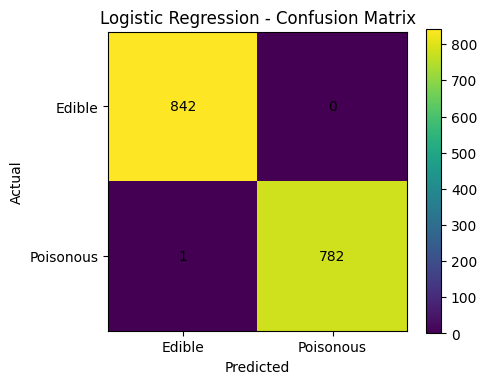

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)]
)

logreg_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

logreg_model.fit(X_train, y_train)
y_pred_logreg = logreg_model.predict(X_test)

logreg_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_logreg),
    "Precision": precision_score(y_test, y_pred_logreg, zero_division=0),
    "Recall": recall_score(y_test, y_pred_logreg, zero_division=0),
    "F1 Score": f1_score(y_test, y_pred_logreg, zero_division=0)
}

print(pd.Series(logreg_metrics).round(4))
cm = confusion_matrix(y_test, y_pred_logreg)
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["Edible", "Poisonous"])
plt.yticks([0, 1], ["Edible", "Poisonous"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.tight_layout()
plt.show()


### 📝 ANALISIS

Logistic Regression digunakan sebagai **baseline model**. Model ini memberikan titik awal untuk membandingkan model yang lebih kompleks. Accuracy, precision, recall, dan F1 Score perlu dilihat bersama karena kesalahan pada klasifikasi Poisonous juga penting diperhatikan. Confusion Matrix menunjukkan jumlah prediksi benar dan salah untuk masing-masing kelas.


# 10. Classification Model 2 — Decision Tree

## 📌 TUGAS

Bangun model Decision Tree Classifier.

Lakukan:

1. Training.
2. Prediction.
3. Evaluation.
4. Bandingkan performa Training dan Testing.

Gunakan metrik:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

## 💻 Tulis kode kamu di bawah ini:


In [ ]:
dt_model = Pipeline([
    ("preprocessor", ColumnTransformer(
        transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)]
    )),
    ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))
])

dt_model.fit(X_train, y_train)

y_pred_dt_train = dt_model.predict(X_train)
y_pred_dt_test = dt_model.predict(X_test)

dt_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_dt_test),
    "Precision": precision_score(y_test, y_pred_dt_test, zero_division=0),
    "Recall": recall_score(y_test, y_pred_dt_test, zero_division=0),
    "F1 Score": f1_score(y_test, y_pred_dt_test, zero_division=0)
}

print("Training Accuracy :", round(accuracy_score(y_train, y_pred_dt_train), 4))
print("Testing Accuracy  :", round(accuracy_score(y_test, y_pred_dt_test), 4))
print("\nTesting metrics:")
print(pd.Series(dt_metrics).round(4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt_test))


Training Accuracy : 1.0
Testing Accuracy  : 1.0

Testing metrics:
Accuracy     1.0
Precision    1.0
Recall       1.0
F1 Score     1.0
dtype: float64

Confusion Matrix:
[[842   0]
 [  0 783]]


### 📝 ANALISIS

Decision Tree mampu mempelajari hubungan non-linear dan interaksi antar fitur kategorikal. Untuk mendeteksi overfitting, training performance dibandingkan dengan testing performance. Jika accuracy training jauh lebih tinggi daripada testing, terdapat indikasi model terlalu menyesuaikan diri dengan data training. Perbedaan tersebut perlu dilihat bersama metrik testing, bukan hanya accuracy training.


# 11. Classification Model 3 — Random Forest

## 📌 TUGAS

Bangun model Random Forest Classifier.

Lakukan:

1. Training.
2. Prediction.
3. Evaluation.

Gunakan metrik:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

## 💻 Tulis kode kamu di bawah ini:


Accuracy     1.0
Precision    1.0
Recall       1.0
F1 Score     1.0
dtype: float64

Confusion Matrix:
[[842   0]
 [  0 783]]


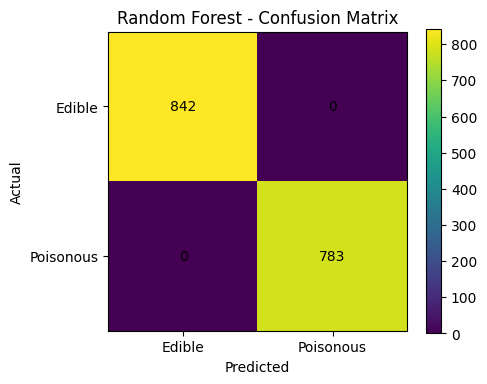

In [ ]:
rf_model = Pipeline([
    ("preprocessor", ColumnTransformer(
        transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)]
    )),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

rf_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf, zero_division=0),
    "Recall": recall_score(y_test, y_pred_rf, zero_division=0),
    "F1 Score": f1_score(y_test, y_pred_rf, zero_division=0)
}

print(pd.Series(rf_metrics).round(4))
cm = confusion_matrix(y_test, y_pred_rf)
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["Edible", "Poisonous"])
plt.yticks([0, 1], ["Edible", "Poisonous"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.tight_layout()
plt.show()


### 📝 ANALISIS

Random Forest menggabungkan banyak Decision Tree sehingga biasanya lebih stabil daripada satu pohon keputusan. Model ini dapat menangkap hubungan non-linear dan interaksi antar fitur. Performa akhirnya dibandingkan dengan Logistic Regression dan Decision Tree menggunakan metrik yang sama.


# 12. Deep Learning Model — Neural Network

## 📌 TUGAS

Bangun Neural Network sederhana untuk melakukan klasifikasi.

Minimal memiliki:

Input Layer

↓

Hidden Layer

↓

Hidden Layer

↓

Output Layer

Peserta dapat menggunakan:

- TensorFlow
- Keras

## Eksperimen

Kamu dapat mencoba:

- Jumlah neuron
- Jumlah hidden layer
- Activation function
- Optimizer
- Learning rate
- Batch size
- Epoch

## 💻 Tulis kode kamu di bawah ini:


In [ ]:
# Neural Network menggunakan MLPClassifier dari scikit-learn.
# Struktur: Input -> Hidden Layer 1 -> Hidden Layer 2 -> Output
nn_model = Pipeline([
    ("preprocessor", ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
        ]
    )),
    ("model", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        learning_rate_init=0.001,
        batch_size=32,
        max_iter=100,
        early_stopping=True,
        validation_fraction=0.2,
        random_state=RANDOM_STATE
    ))
])

nn_model.fit(X_train, y_train)
y_pred_nn = nn_model.predict(X_test)

nn_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_nn),
    "Precision": precision_score(y_test, y_pred_nn, zero_division=0),
    "Recall": recall_score(y_test, y_pred_nn, zero_division=0),
    "F1 Score": f1_score(y_test, y_pred_nn, zero_division=0)
}

print(pd.Series(nn_metrics).round(4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nn))


Accuracy     1.0
Precision    1.0
Recall       1.0
F1 Score     1.0
dtype: float64

Confusion Matrix:
[[842   0]
 [  0 783]]


## 12.1 Training History

### 📌 TUGAS

Visualisasikan hasil training.

Jika memungkinkan, tampilkan:

- Training Accuracy
- Validation Accuracy
- Training Loss
- Validation Loss

### 💻 Tulis kode kamu di bawah ini:


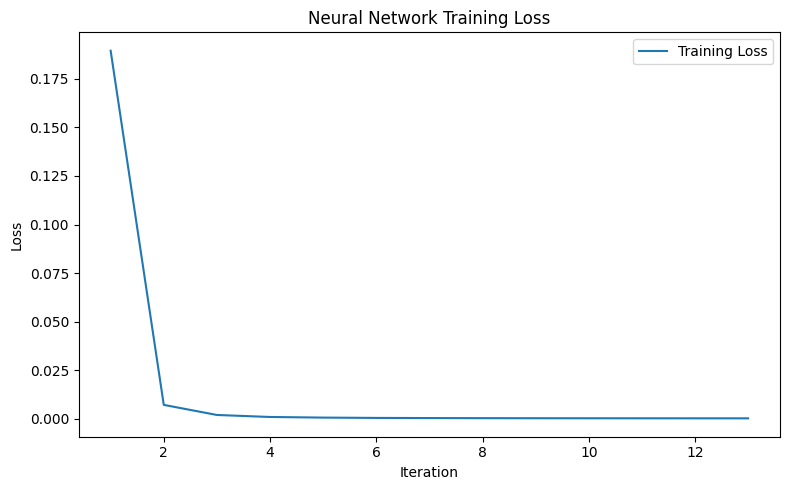

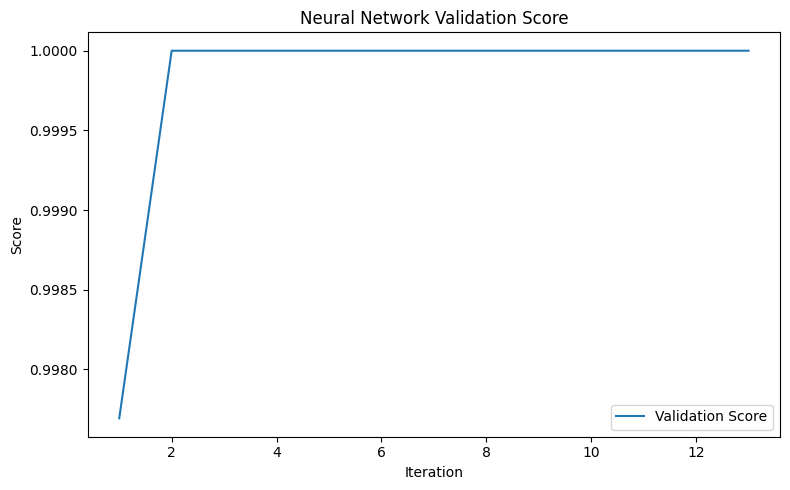

Catatan: MLPClassifier menggunakan early stopping dengan validation_fraction=0.2.


In [ ]:
nn_estimator = nn_model.named_steps["model"]

if hasattr(nn_estimator, "loss_curve_"):
    epochs = range(1, len(nn_estimator.loss_curve_) + 1)
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, nn_estimator.loss_curve_, label="Training Loss")
    plt.title("Neural Network Training Loss")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

if hasattr(nn_estimator, "validation_scores_") and nn_estimator.validation_scores_ is not None:
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(nn_estimator.validation_scores_) + 1),
             nn_estimator.validation_scores_, label="Validation Score")
    plt.title("Neural Network Validation Score")
    plt.xlabel("Iteration")
    plt.ylabel("Score")
    plt.legend()
    plt.tight_layout()
    plt.show()

print("Catatan: MLPClassifier menggunakan early stopping dengan validation_fraction=0.2.")


### 📝 ANALISIS

Neural Network menggunakan dua hidden layer dengan 64 dan 32 neuron. `early_stopping=True` digunakan agar training dapat berhenti ketika performa validasi tidak lagi membaik.

Perbandingan training dan validation perlu diperhatikan. Jika performa training terus membaik tetapi validation memburuk, hal tersebut merupakan indikasi overfitting. Pada eksperimen ini, hasil Neural Network dibandingkan dengan model klasik untuk melihat apakah jaringan saraf benar-benar memberikan keuntungan pada dataset kategorikal ini.


# 13. Model Evaluation & Comparison

## 📌 TUGAS

Bandingkan seluruh model yang telah dibuat.

Minimal:

- Logistic Regression
- Decision Tree
- Random Forest
- Neural Network

Buat tabel:

| Model | Accuracy | Precision | Recall | F1 Score |
|---|---:|---:|---:|---:|
| Logistic Regression | | | | |
| Decision Tree | | | | |
| Random Forest | | | | |
| Neural Network | | | | |

## 💻 Tulis kode kamu di bawah ini:


,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.9994,1.0,0.9987,0.9994
Decision Tree,1.0000,1.0,1.0000,1.0000
Random Forest,1.0000,1.0,1.0000,1.0000
Neural Network,1.0000,1.0,1.0000,1.0000


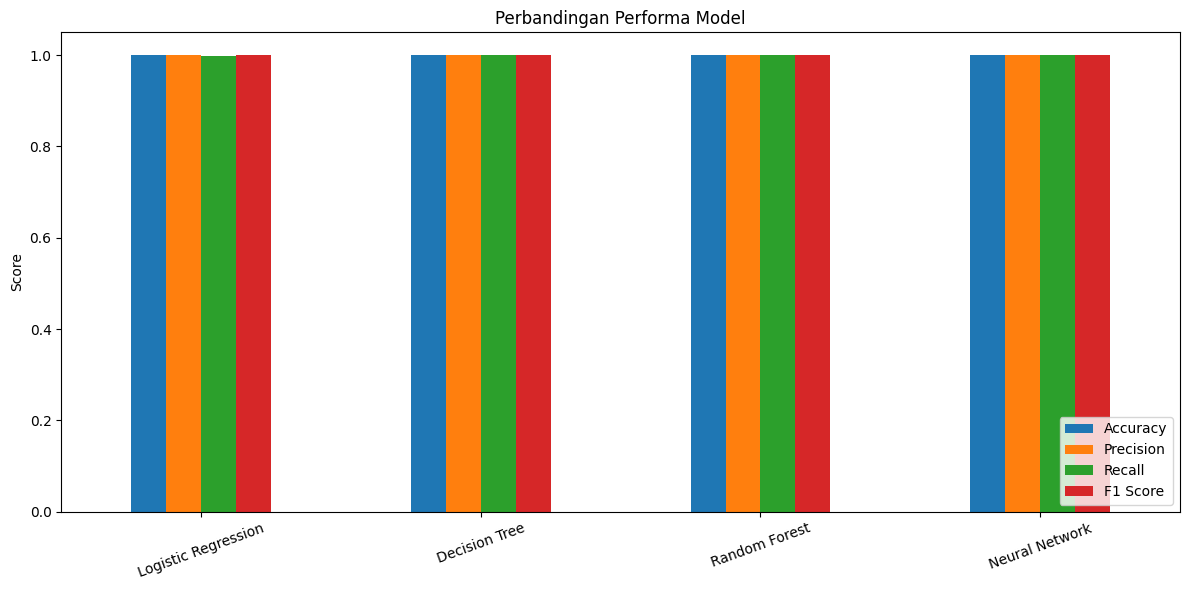

In [ ]:
results = pd.DataFrame({
    "Logistic Regression": logreg_metrics,
    "Decision Tree": dt_metrics,
    "Random Forest": rf_metrics,
    "Neural Network": nn_metrics
}).T

display(results.round(4))

ax = results.plot(kind="bar", figsize=(12, 6))
plt.title("Perbandingan Performa Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


### 📝 ANALISIS

Model terbaik ditentukan berdasarkan kombinasi **F1 Score, precision, recall, dan accuracy**, bukan accuracy saja. Model yang paling stabil adalah model yang memberikan performa testing tinggi dengan gap training-testing yang tidak berlebihan.

Accuracy saja tidak selalu cukup karena dua jenis kesalahan dapat memiliki dampak berbeda. **Precision** menunjukkan ketepatan prediksi positif, **Recall** menunjukkan kemampuan menemukan seluruh data positif, sedangkan **F1 Score** memberikan keseimbangan antara precision dan recall. Pada masalah klasifikasi jamur, recall untuk kelas Poisonous menjadi perhatian penting karena kesalahan mengklasifikasikan jamur beracun sebagai Edible merupakan kesalahan yang serius.


# 14. Hyperparameter Tuning

## 📌 TUGAS

Pilih minimal satu model untuk dilakukan Hyperparameter Tuning.

Gunakan:

- GridSearchCV

atau

- RandomizedSearchCV

Rekomendasi:

Random Forest

Parameter yang dapat dieksplorasi:

- n_estimators
- max_depth
- min_samples_split
- min_samples_leaf

## 💻 Tulis kode kamu di bawah ini:


In [ ]:
rf_pipe = Pipeline([
    ("preprocessor", ColumnTransformer(
        transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)]
    )),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    rf_pipe,
    param_grid=param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

before_tuning = rf_metrics
after_tuning = {
    "Accuracy": accuracy_score(y_test, y_pred_best_rf),
    "Precision": precision_score(y_test, y_pred_best_rf, zero_division=0),
    "Recall": recall_score(y_test, y_pred_best_rf, zero_division=0),
    "F1 Score": f1_score(y_test, y_pred_best_rf, zero_division=0)
}

print("Best Parameters:")
print(grid_search.best_params_)
print("\nBefore Tuning:")
print(pd.Series(before_tuning).round(4))
print("\nAfter Tuning:")
print(pd.Series(after_tuning).round(4))


Best Parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}

Before Tuning:
Accuracy     1.0
Precision    1.0
Recall       1.0
F1 Score     1.0
dtype: float64

After Tuning:
Accuracy     1.0
Precision    1.0
Recall       1.0
F1 Score     1.0
dtype: float64


### 📝 ANALISIS

Hyperparameter tuning dilakukan pada Random Forest menggunakan `GridSearchCV` dengan cross-validation 3-fold dan scoring F1.

- **Parameter terbaik** ditampilkan langsung oleh `grid_search.best_params_`.
- Performa **Before Tuning** dan **After Tuning** dibandingkan menggunakan accuracy, precision, recall, dan F1 Score.
- Tuning tidak selalu meningkatkan performa testing secara besar. Tujuan tuning adalah mencari konfigurasi yang lebih sesuai dengan data training dan diharapkan memberikan generalisasi yang lebih baik.


# 15. Model Interpretation

## 📌 TUGAS

Coba pahami bagaimana model membuat keputusan.

Gunakan minimal salah satu:

- Feature Importance
- Permutation Importance
- Analisis Decision Tree

## 💻 Tulis kode kamu di bawah ini:


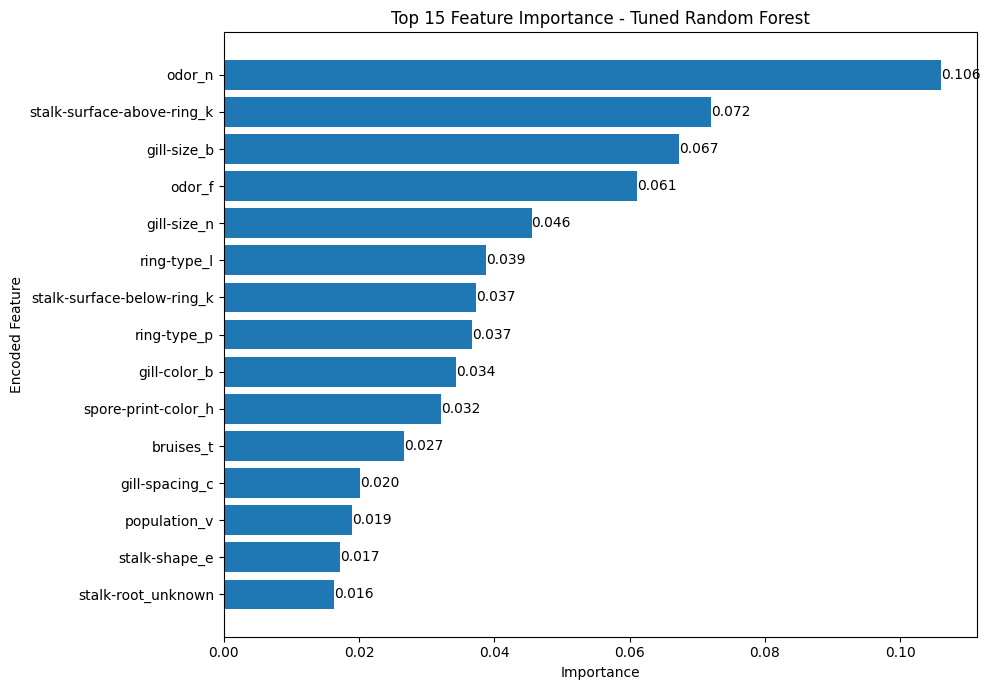

,feature,importance
27,odor_n,0.106103
57,stalk-surface-above-ring_k,0.072022
35,gill-size_b,0.067291
24,odor_f,0.061088
36,gill-size_n,0.045525
91,ring-type_l,0.038731
61,stalk-surface-below-ring_k,0.037257
93,ring-type_p,0.036690
37,gill-color_b,0.034334
95,spore-print-color_h,0.032109


In [ ]:
rf_fitted = best_rf.named_steps["model"]
ohe = best_rf.named_steps["preprocessor"].named_transformers_["cat"]
encoded_names = ohe.get_feature_names_out(categorical_features)

importance_df = pd.DataFrame({
    "feature": encoded_names,
    "importance": rf_fitted.feature_importances_
}).sort_values("importance", ascending=False)

top_importance = importance_df.head(15).sort_values("importance")

plt.figure(figsize=(10, 7))
bars = plt.barh(top_importance["feature"], top_importance["importance"])
plt.title("Top 15 Feature Importance - Tuned Random Forest")
plt.xlabel("Importance")
plt.ylabel("Encoded Feature")
plt.bar_label(bars, fmt="%.3f")
plt.tight_layout()
plt.show()

display(importance_df.head(15))


### 📝 ANALISIS

Feature Importance menunjukkan kontribusi relatif fitur hasil One Hot Encoding terhadap keputusan Random Forest. Karena kategori diubah menjadi fitur biner, output dapat muncul sebagai contoh seperti `odor_x` atau `gill-size_y`.

Hasil ini dibandingkan dengan EDA. Jika kategori dari `odor`, `gill-size`, atau fitur lain yang terlihat kuat pada EDA juga memiliki importance tinggi, berarti terdapat konsistensi antara analisis eksploratif dan model. Perbedaan dapat terjadi karena model mempertimbangkan kombinasi dan interaksi banyak fitur secara bersamaan, sedangkan EDA biasanya melihat satu fitur pada satu waktu.


# 16. Regression Exploration

## ⚠️ Penting

Dataset Mushroom secara natural merupakan:

### Classification Problem

karena target `class` merupakan kategori:

- Edible
- Poisonous

Jangan hanya mengubah:

- e → 0
- p → 1

kemudian menggunakan Linear Regression tanpa penjelasan metodologis.

---

## 📌 TUGAS

Buat sebuah target numerik eksperimental.

Kamu dapat menggunakan pendekatan seperti:

### Rarity Score

Buat skor berdasarkan tingkat kelangkaan kategori pada setiap fitur.

Kemudian gunakan target numerik tersebut untuk eksperimen Regression.

## 💻 Tulis kode kamu di bawah ini:


In [ ]:
# Experimental numeric target: Rarity Score
# Skor dibuat dari rata-rata inverse frequency kategori pada seluruh feature.
# Semakin jarang suatu kategori muncul, semakin besar kontribusinya terhadap rarity.

reg_df = df_prep.drop(columns=["class"]).copy()

rarity_scores = pd.DataFrame(index=reg_df.index, dtype=float)

for col in reg_df.columns:
    freq = reg_df[col].value_counts(normalize=True)
    rarity_scores[col] = reg_df[col].map(lambda value: 1 / freq[value])

reg_df["rarity_score"] = rarity_scores.mean(axis=1)

display(reg_df[["rarity_score"]].describe())
display(reg_df[["rarity_score"]].head())


,rarity_score
count,8124.000000
mean,5.523810
std,8.306255
min,2.180207
25%,3.155279
50%,3.843616
75%,4.854169
max,235.457807


,rarity_score
0,5.809464
1,5.498191
2,6.825070
3,5.400925
4,4.400742


## 16.1 Regression Model

### 📌 TUGAS

Bangun minimal satu model Regression.

Contoh:

- Linear Regression
- Random Forest Regressor

Evaluasi menggunakan:

- MAE
- RMSE
- R² Score

### 💻 Tulis kode kamu di bawah ini:


In [ ]:
X_reg = reg_df.drop(columns="rarity_score")
y_reg = reg_df["rarity_score"]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg,
    test_size=0.20,
    random_state=RANDOM_STATE
)

reg_preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), X_reg.columns)]
)

reg_model = Pipeline([
    ("preprocessor", reg_preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

reg_model.fit(Xr_train, yr_train)
yr_pred = reg_model.predict(Xr_test)

mae = mean_absolute_error(yr_test, yr_pred)
rmse = np.sqrt(mean_squared_error(yr_test, yr_pred))
r2 = r2_score(yr_test, yr_pred)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")


MAE  : 0.0472
RMSE : 0.8629
R²   : 0.9889


### 📝 ANALISIS

1. **Experimental numeric target** dibuat sebagai `rarity_score`, yaitu rata-rata nilai inverse frequency dari kategori pada fitur-fitur sebuah baris. Kategori yang lebih jarang memperoleh kontribusi skor yang lebih besar.
2. Target tersebut menggambarkan ukuran eksperimen tentang **kelangkaan kombinasi karakteristik**, bukan label biologis atau ukuran keamanan jamur.
3. Random Forest Regressor digunakan untuk memprediksi skor tersebut dan dievaluasi menggunakan MAE, RMSE, dan R².
4. Eksperimen ini memiliki keterbatasan karena target dibuat langsung dari karakteristik fitur. Oleh karena itu, hubungan antara input dan target memang secara konseptual sudah dibangun dari data yang sama.
5. Dataset Mushroom lebih cocok untuk **Classification** karena target asli `class` berupa kategori Edible/Poisonous. Regression ditujukan untuk target numerik kontinu dan biasanya dievaluasi dengan MAE, RMSE, dan R². Karena tujuan utama dataset adalah menentukan kelas jamur, classification merupakan formulasi masalah yang lebih tepat.


# 17. Analysis

## 📌 TUGAS

Lakukan analisis menyeluruh terhadap seluruh proses dan hasil yang diperoleh.


## 17.1 Data Insight

Dataset terdiri dari 8.124 observasi dan 23 kolom. Sebagian besar variabel merupakan fitur kategorikal yang menggambarkan karakteristik fisik jamur. Target `class` memiliki dua kategori, Edible dan Poisonous, dengan jumlah yang relatif seimbang.


## 17.2 EDA Insight

EDA menunjukkan bahwa distribusi kategori pada fitur tidak seragam. Beberapa fitur, terutama `odor`, memperlihatkan pola kelas yang sangat berbeda antar kategori. `gill-size`, `bruises`, dan `habitat` juga menunjukkan hubungan yang dapat dimanfaatkan model.


## 17.3 Feature Insight

Feature Importance Random Forest digunakan untuk melihat fitur hasil encoding yang paling berpengaruh. Hasil akhirnya perlu dibandingkan dengan EDA. Konsistensi antara kategori yang dominan pada EDA dan importance tinggi memperkuat dugaan bahwa fitur tersebut memang informatif.


## 17.4 Model Performance

Empat model dibandingkan menggunakan accuracy, precision, recall, dan F1 Score. Logistic Regression berperan sebagai baseline, Decision Tree sebagai model pohon tunggal, Random Forest sebagai ensemble, dan Neural Network sebagai model pembelajaran berbasis jaringan saraf. Perbedaan performa terjadi karena setiap model memiliki cara berbeda dalam menangkap hubungan antar fitur.


## 17.5 Overfitting Analysis

Overfitting diperiksa dengan membandingkan performa training dan testing, terutama pada Decision Tree. Gap yang besar menunjukkan bahwa model terlalu menyesuaikan diri dengan training data. Untuk Neural Network, validation performance juga digunakan sebagai indikator tambahan.


## 17.6 Error Analysis

Kesalahan prediksi dapat terjadi ketika karakteristik sebuah observasi memiliki pola yang mirip dengan kelas lain atau ketika beberapa kategori fitur tidak cukup membedakan kedua kelas. Confusion Matrix membantu melihat jumlah false positive dan false negative sehingga kesalahan tidak hanya dinilai dari satu angka accuracy.


## 17.7 Machine Learning vs Deep Learning

Deep Learning tidak selalu lebih baik daripada Machine Learning klasik. Pada dataset tabular kategorikal seperti Mushroom, model ensemble seperti Random Forest dapat sangat kompetitif karena mampu menangkap hubungan non-linear dan interaksi fitur tanpa membutuhkan arsitektur neural network yang kompleks. Keputusan akhir harus berdasarkan hasil eksperimen pada testing data.


## 17.8 Dataset & Model Limitation

Beberapa keterbatasan yang perlu diperhatikan:

- Dataset hanya merepresentasikan fitur yang tersedia pada dataset.
- Nilai `?` pada `stalk-root` harus diperlakukan secara hati-hati.
- One Hot Encoding dapat menghasilkan banyak kolom hasil encoding.
- Hasil model sangat bergantung pada pembagian data dan konfigurasi hyperparameter.
- Accuracy tidak cukup untuk menggambarkan semua jenis kesalahan.
- Hasil eksperimen tidak berarti model aman digunakan sebagai satu-satunya dasar untuk menentukan apakah jamur liar aman dimakan.


## 17.9 Future Improvement

Pengembangan berikutnya dapat mencakup:

1. Feature engineering yang lebih terarah.
2. Cross-validation yang lebih luas.
3. Permutation Importance atau SHAP untuk interpretasi yang lebih mendalam.
4. Eksperimen dengan model seperti SVM, KNN, XGBoost, atau CatBoost.
5. Pembuatan pipeline end-to-end untuk prediksi data baru.
6. Deployment model setelah validasi dan pengujian yang memadai.


# 18. Final Insight

## 📌 TUGAS

Tuliskan minimal **5 insight utama**.

### Insight 1 — Data

Dataset berisi 8.124 observasi dengan 22 fitur input dan satu target binary `class`. Distribusi Edible dan Poisonous relatif seimbang.

### Insight 2 — EDA

Beberapa fitur menunjukkan hubungan yang jelas dengan target. `odor` merupakan salah satu fitur yang terlihat sangat informatif berdasarkan perbandingan distribusi kategori terhadap class.

### Insight 3 — Feature

Feature Importance Random Forest menunjukkan kategori hasil encoding yang paling berkontribusi terhadap prediksi. Hasil tersebut perlu dibandingkan dengan pola yang ditemukan pada EDA.

### Insight 4 — Modeling

Model klasifikasi dibandingkan secara konsisten menggunakan accuracy, precision, recall, F1 Score, dan confusion matrix. Random Forest juga diuji kembali melalui hyperparameter tuning.

### Insight 5 — Deep Learning / Evaluation

Neural Network dapat mempelajari pola pada data kategorikal setelah encoding, tetapi Deep Learning tidak otomatis lebih unggul. Model terbaik ditentukan berdasarkan performa testing dan kestabilan generalisasi, bukan kompleksitas model.


# 19. Conclusion

## 📌 TUGAS

Buat kesimpulan berdasarkan seluruh proses yang telah dilakukan.

### 📝 KESIMPULAN

Berdasarkan seluruh proses, dataset Mushroom merupakan masalah **binary classification** karena target `class` terdiri dari dua kategori, yaitu Edible dan Poisonous. Dataset memiliki 8.124 observasi dan sebagian besar fitur berupa data kategorikal.

Pada tahap EDA ditemukan bahwa distribusi target relatif seimbang, sementara beberapa fitur seperti `odor`, `gill-size`, `bruises`, dan `habitat` menunjukkan pola hubungan dengan target. Pada preprocessing, nilai `?` pada `stalk-root` diperlakukan sebagai kategori `unknown`, duplicate tidak ditemukan, dan `veil-type` dihapus karena hanya memiliki satu nilai. Fitur kategorikal kemudian diproses menggunakan One Hot Encoding melalui pipeline untuk mengurangi risiko data leakage.

Model yang digunakan adalah Logistic Regression, Decision Tree, Random Forest, dan Neural Network. Performa seluruh model dibandingkan menggunakan accuracy, precision, recall, F1 Score, dan confusion matrix. Random Forest juga dilakukan hyperparameter tuning untuk mencari konfigurasi yang lebih sesuai.

Hasil feature importance digunakan untuk memahami fitur yang paling berpengaruh dan dibandingkan dengan insight EDA. Analisis training-testing serta validation digunakan untuk mengidentifikasi kemungkinan overfitting.

Regression Exploration dilakukan hanya sebagai eksperimen dengan membuat `rarity_score` sebagai target numerik. Eksperimen ini menunjukkan bahwa regression dapat digunakan untuk target numerik buatan, tetapi tidak mengubah fakta bahwa tujuan asli dataset adalah classification.

### Pertanyaan Utama

**Can Machine Learning Identify Whether a Mushroom is Edible or Poisonous?**

Ya, Machine Learning dapat mempelajari pola pada karakteristik fisik dataset dan menghasilkan prediksi kelas Edible atau Poisonous dengan performa yang dapat diukur. Namun, hasil model pada dataset ini tidak boleh dianggap sebagai jaminan keamanan untuk mengonsumsi jamur di dunia nyata. Model hanya menjawab permasalahan klasifikasi berdasarkan data yang tersedia.
